<style>
/* Paper-style layout for both Jupyter and nbconvert HTML. */
.jp-Notebook,
.jp-NotebookPanel-notebook,
main {
    max-width: 1080px;
    margin-left: auto !important;
    margin-right: auto !important;
}

.jp-RenderedHTMLCommon p,
.text_cell_render p {
    text-align: justify;
    text-justify: inter-word;
    line-height: 1.65;
}

.jp-OutputArea-output img,
.jp-RenderedImage img,
.output_png img,
div.output_area img,
div.output_subarea img {
    display: block;
    max-width: 94%;
    height: auto;
    margin: 0.4rem auto 0.6rem !important;
}

.figure-caption {
    margin: 0.65rem auto 0.25rem !important;
    text-align: center !important;
    font-size: 1rem;
    line-height: 1.45 !important;
}

.figure-interpretation {
    max-width: 94%;
    margin: 0.35rem auto 1.75rem !important;
    text-align: justify !important;
    text-justify: inter-word;
    line-height: 1.65 !important;
}

.interpretation-label {
    font-style: italic;
    font-weight: 600;
}
</style>

# Conditional Expectation: Information, Projection, and Refinement


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Markdown, display

plt.rcParams.update({
    "figure.figsize": (9, 4.8),
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "legend.fontsize": 10,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
})

BLUE = "#4C78A8"
ORANGE = "#F58518"
GREEN = "#54A24B"
RED = "#E45756"
GREY = "#6B7280"


def conditional_mean(values, group_ids):
    # Conditional mean for equally likely finite outcomes.
    values = np.asarray(values, dtype=float)
    group_ids = np.asarray(group_ids)
    result = np.empty_like(values)
    for group in np.unique(group_ids):
        mask = group_ids == group
        result[mask] = values[mask].mean()
    return result

## 1. Information as a partition

For $X\in L^2(\Omega,\Sigma,\mathbb{P})$, the conditional expectation $Y=\mathbb{E}(X\mid\Sigma_0)$ is the $\Sigma_0$-measurable random variable in $L^2(\Omega,\Sigma_0,\mathbb{P})$ satisfying

$$
\int_A Y\,d\mathbb{P}=\int_A X\,d\mathbb{P}\qquad\text{for every }A\in\Sigma_0.
$$

It is unique up to almost-sure equality. Conditioning on an event is a related scalar quantity: if $\mathbb{P}(A_0)>0$, then $\mathbb{E}(X\mid A_0)=\mathbb{P}(A_0)^{-1}\int_{A_0}X\,d\mathbb{P}$, whereas conditioning on a sigma-algebra produces a random variable.

Consider two fair coin tosses with four equally likely outcomes: $HH$, $HT$, $TH$, and $TT$. Let $\Sigma_0$ be the sigma-algebra generated by the first toss, which partitions the sample space into

$$
\{HH,HT\}\quad\text{and}\quad\{TH,TT\}.
$$

In this finite example, $\mathbb{E}(X\mid\Sigma_0)$ is the average payoff within each row of the partition.

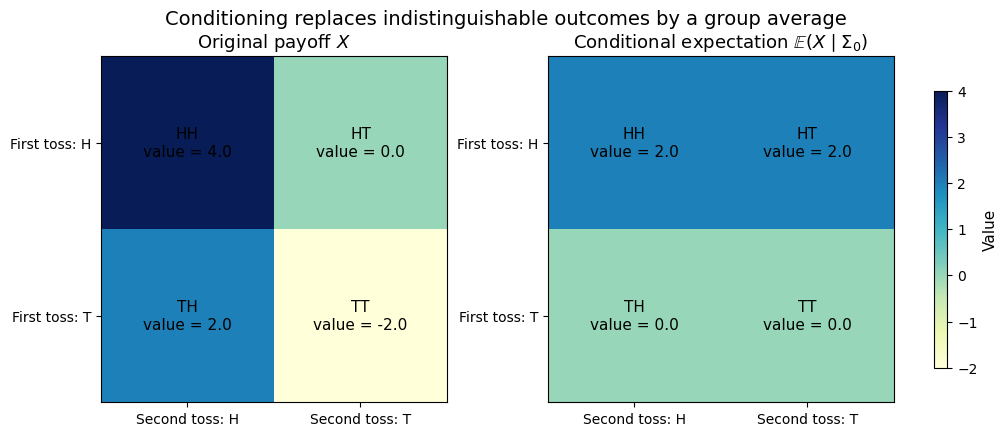

In [2]:
outcomes = np.array([["HH", "HT"], ["TH", "TT"]])
payoff = np.array([[4.0, 0.0], [2.0, -2.0]])
given_first_toss = np.repeat(payoff.mean(axis=1, keepdims=True), 2, axis=1)

fig, axes = plt.subplots(1, 2, figsize=(10, 4.2), constrained_layout=True)
vmin, vmax = payoff.min(), payoff.max()

for ax, values, title in zip(
    axes,
    [payoff, given_first_toss],
    ["Original payoff $X$", r"Conditional expectation $\mathbb{E}(X\mid\Sigma_0)$"],
):
    image = ax.imshow(values, cmap="YlGnBu", vmin=vmin, vmax=vmax)
    for row in range(2):
        for col in range(2):
            ax.text(
                col,
                row,
                f"{outcomes[row, col]}\nvalue = {values[row, col]:.1f}",
                ha="center",
                va="center",
                color="black",
                fontsize=11,
            )
    ax.set_xticks([0, 1], labels=["Second toss: H", "Second toss: T"])
    ax.set_yticks([0, 1], labels=["First toss: H", "First toss: T"])
    ax.set_title(title)

fig.colorbar(image, ax=axes, shrink=0.8, label="Value")
fig.suptitle("Conditioning replaces indistinguishable outcomes by a group average", fontsize=14)
plt.show()

<p class="figure-caption"><strong>Figure 1.</strong> Conditional averaging with respect to $\Sigma_0$, the sigma-algebra generated by the first toss.</p>

<p class="figure-interpretation"><span class="interpretation-label">Interpretation.</span> The right panel is constant on each atom of $\Sigma_0$, so it is $\Sigma_0$-measurable. For $A_H=\{HH,HT\}$, the defining identity holds because $\int_{A_H}X\,d\mathbb{P}=(4+0)/4=1$ and $\int_{A_H}\mathbb{E}(X\mid\Sigma_0)\,d\mathbb{P}=2\mathbb{P}(A_H)=1$; the same check gives $0$ on $A_T=\{TH,TT\}$. The scalar event-conditioned value is $\mathbb{E}(X\mid A_H)=2$, while the sigma-algebra-conditioned random variable equals $2$ on $A_H$ and $0$ on $A_T$.</p>

## 2. Projection geometry

Let $\Sigma_0\subset\Sigma$ be a sub-sigma-algebra and set $Y=\mathbb{E}(X\mid\Sigma_0)$. The square-integrable $\Sigma_0$-measurable random variables form the closed subspace $L^2(\Omega,\Sigma_0,\mathbb{P})$ of $L^2(\Omega,\Sigma,\mathbb{P})$. From the defining identity,

$$
\mathbb{E}\left[(X-Y)\mathbf{1}_A\right]=0\qquad\text{for every }A\in\Sigma_0.
$$

By linearity and approximation by $\Sigma_0$-measurable simple functions, $\mathbb{E}[(X-Y)Z]=0$ for every $Z\in L^2(\Omega,\Sigma_0,\mathbb{P})$. Thus $Y$ is the orthogonal projection of $X$ onto that subspace. For every admissible estimate $Z$,

$$
\mathbb{E}\left[(X-Z)^2\right]=\mathbb{E}\left[(X-Y)^2\right]+\mathbb{E}\left[(Y-Z)^2\right].
$$

Hence $Y$ is the unique (up to a.s. equality) minimiser of mean-square error.

The schematic below represents the projection, the admissible subspace, and the residual in two dimensions.

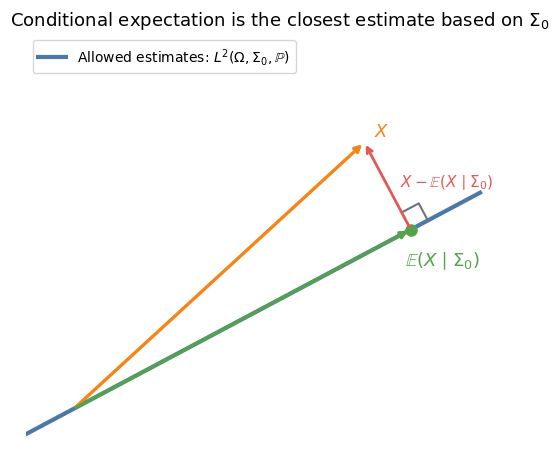

In [3]:
angle = np.deg2rad(28)
direction = np.array([np.cos(angle), np.sin(angle)])
x_vector = np.array([2.4, 2.2])
projection = np.dot(x_vector, direction) * direction

line_parameter = np.linspace(-0.5, 3.8, 100)
line_points = np.outer(line_parameter, direction)

fig, ax = plt.subplots(figsize=(8, 5.5))
ax.plot(
    line_points[:, 0],
    line_points[:, 1],
    color=BLUE,
    linewidth=3,
    label=r"Allowed estimates: $L^2(\Omega,\Sigma_0,\mathbb{P})$",
)

ax.annotate("", xy=x_vector, xytext=(0, 0), arrowprops={"arrowstyle": "->", "lw": 2.4, "color": ORANGE})
ax.annotate("", xy=projection, xytext=(0, 0), arrowprops={"arrowstyle": "->", "lw": 2.4, "color": GREEN})
ax.annotate("", xy=x_vector, xytext=projection, arrowprops={"arrowstyle": "->", "lw": 2.0, "color": RED})

# Mark the right angle between the projection subspace and the residual.
residual_direction = (x_vector - projection) / np.linalg.norm(x_vector - projection)
marker_size = 0.16
corner_1 = projection + marker_size * direction
corner_2 = corner_1 + marker_size * residual_direction
corner_3 = projection + marker_size * residual_direction
ax.plot(
    [corner_1[0], corner_2[0], corner_3[0]],
    [corner_1[1], corner_2[1], corner_3[1]],
    color=GREY,
    linewidth=1.5,
)

ax.plot([projection[0]], [projection[1]], "o", color=GREEN, markersize=8)
ax.text(x_vector[0] + 0.08, x_vector[1] + 0.05, "$X$", color=ORANGE, fontsize=13)
ax.text(projection[0] - 0.05, projection[1] - 0.3, r"$\mathbb{E}(X\mid\Sigma_0)$", color=GREEN, fontsize=13)
midpoint = (projection + x_vector) / 2
ax.text(midpoint[0] + 0.1, midpoint[1], r"$X-\mathbb{E}(X\mid\Sigma_0)$", color=RED, fontsize=11)

ax.set_title(r"Conditional expectation is the closest estimate based on $\Sigma_0$")
ax.set_aspect("equal")
ax.set_xlim(-0.4, 3.8)
ax.set_ylim(-0.4, 3.1)
ax.set_xticks([])
ax.set_yticks([])
ax.legend(loc="upper left")
for spine in ax.spines.values():
    spine.set_visible(False)
plt.show()

<p class="figure-caption"><strong>Figure 2.</strong> Two-dimensional schematic of $\mathbb{E}(X\mid\Sigma_0)$ as an orthogonal projection in $L^2(\Omega,\Sigma,\mathbb{P})$.</p>

<p class="figure-interpretation"><span class="interpretation-label">Interpretation.</span> The diagram depicts $\mathbb{E}(X\mid\Sigma_0)$ inside the admissible subspace and the residual $X-\mathbb{E}(X\mid\Sigma_0)$ orthogonal to it. The right-angle marker is schematic; the Pythagorean identity above supplies the mathematical reason that every other admissible $Z$ adds the nonnegative error $\mathbb{E}[(Y-Z)^2]$.</p>

## 3. Information refinement

Let $\Sigma_1\subset\Sigma_0$ denote coarse and refined information, respectively. In the example below, twelve equally likely states are grouped first into blocks of four under $\Sigma_1$ and then into blocks of two under $\Sigma_0$.

Because $L^2(\Omega,\Sigma_1,\mathbb{P})\subset L^2(\Omega,\Sigma_0,\mathbb{P})$, the refined projection has no larger mean-square error:

$$
\left\|X-\mathbb{E}(X\mid\Sigma_0)\right\|_2\leq\left\|X-\mathbb{E}(X\mid\Sigma_1)\right\|_2.
$$

The tower property in Proposition 1.7 gives the two-sided identity

$$
\mathbb{E}\!\left(\mathbb{E}(X\mid\Sigma_0)\mid\Sigma_1\right)=\mathbb{E}(X\mid\Sigma_1)=\mathbb{E}\!\left(\mathbb{E}(X\mid\Sigma_1)\mid\Sigma_0\right).
$$

The final equality holds because $\mathbb{E}(X\mid\Sigma_1)$ is already $\Sigma_1$-measurable and therefore $\Sigma_0$-measurable.

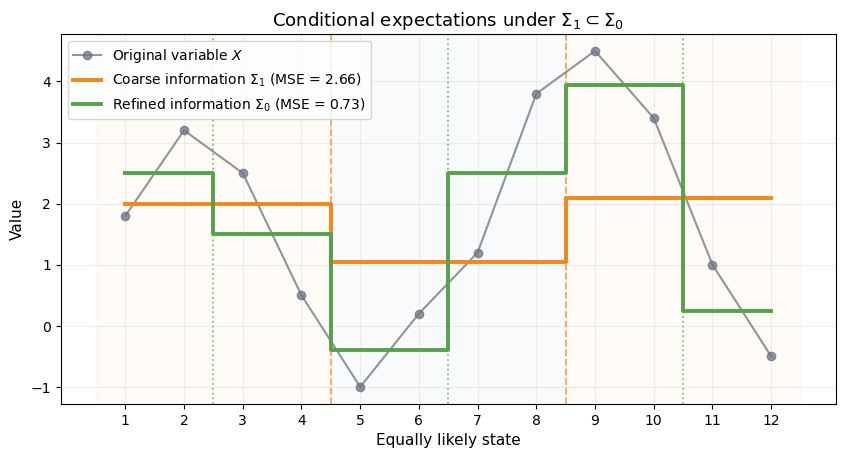


| Diagnostic | Value |
|---|---:|
| $\mathbb{E}(X)$ | 1.717 |
| $\mathbb{E}(\mathbb{E}(X\mid\Sigma_1))$ | 1.717 |
| Tower-property maximum error | 2.220e-16 |


In [4]:
states = np.arange(1, 13)
state_values = np.array([1.8, 3.2, 2.5, 0.5, -1.0, 0.2, 1.2, 3.8, 4.5, 3.4, 1.0, -0.5])

coarse_groups = np.repeat(np.arange(3), 4)
refined_groups = np.repeat(np.arange(6), 2)

coarse_estimate = conditional_mean(state_values, coarse_groups)
refined_estimate = conditional_mean(state_values, refined_groups)

coarse_mse = np.mean((state_values - coarse_estimate) ** 2)
refined_mse = np.mean((state_values - refined_estimate) ** 2)
tower_check = conditional_mean(refined_estimate, coarse_groups)

fig, ax = plt.subplots(figsize=(10, 4.8))

# Alternating background bands and boundary lines show the nested information groups.
for index, (left, right) in enumerate([(0.5, 4.5), (4.5, 8.5), (8.5, 12.5)]):
    ax.axvspan(left, right, color=ORANGE if index % 2 == 0 else BLUE, alpha=0.035, zorder=0)
for boundary in [4.5, 8.5]:
    ax.axvline(boundary, color=ORANGE, linestyle="--", linewidth=1.3, alpha=0.7, zorder=1)
for boundary in [2.5, 6.5, 10.5]:
    ax.axvline(boundary, color=GREEN, linestyle=":", linewidth=1.3, alpha=0.7, zorder=1)

ax.plot(states, state_values, "o-", color=GREY, alpha=0.75, label="Original variable $X$", zorder=3)
ax.step(
    states,
    coarse_estimate,
    where="mid",
    linewidth=2.8,
    color=ORANGE,
    label=rf"Coarse information $\Sigma_1$ (MSE = {coarse_mse:.2f})",
    zorder=3,
)
ax.step(
    states,
    refined_estimate,
    where="mid",
    linewidth=2.8,
    color=GREEN,
    label=rf"Refined information $\Sigma_0$ (MSE = {refined_mse:.2f})",
    zorder=3,
)
ax.set_title(r"Conditional expectations under $\Sigma_1\subset\Sigma_0$")
ax.set_xlabel("Equally likely state")
ax.set_ylabel("Value")
ax.set_xticks(states)
ax.grid(alpha=0.2)
ax.legend()
plt.show()

display(Markdown(rf"""
| Diagnostic | Value |
|---|---:|
| $\mathbb{{E}}(X)$ | {state_values.mean():.3f} |
| $\mathbb{{E}}(\mathbb{{E}}(X\mid\Sigma_1))$ | {coarse_estimate.mean():.3f} |
| Tower-property maximum error | {np.max(np.abs(tower_check - coarse_estimate)):.3e} |
"""))

<p class="figure-caption"><strong>Figure 3.</strong> Conditional expectations under the nested information structure $\Sigma_1\subset\Sigma_0$.</p>

<p class="figure-interpretation"><span class="interpretation-label">Interpretation.</span> Dashed orange lines mark the boundaries of the coarse $\Sigma_1$ groups, while dotted green lines mark the additional distinctions available under $\Sigma_0$. Refinement reduces the mean-square error from $2.66$ to $0.73$; averaging $\mathbb{E}(X\mid\Sigma_0)$ over each $\Sigma_1$ group recovers $\mathbb{E}(X\mid\Sigma_1)$, and both estimates retain $\mathbb{E}(X)=1.717$.</p>

## 4. Conditional Jensen inequality

Using the coarser sigma-algebra $\Sigma_1$ from the previous section and the convex function $\phi(x)=x^2$, Proposition 1.7 gives, almost surely,

$$
\left(\mathbb{E}(X\mid\Sigma_1)\right)^2 \leq \mathbb{E}(X^2\mid\Sigma_1).
$$

Each pair of bars compares the squared conditional mean with the conditional second moment inside one $\Sigma_1$ group.

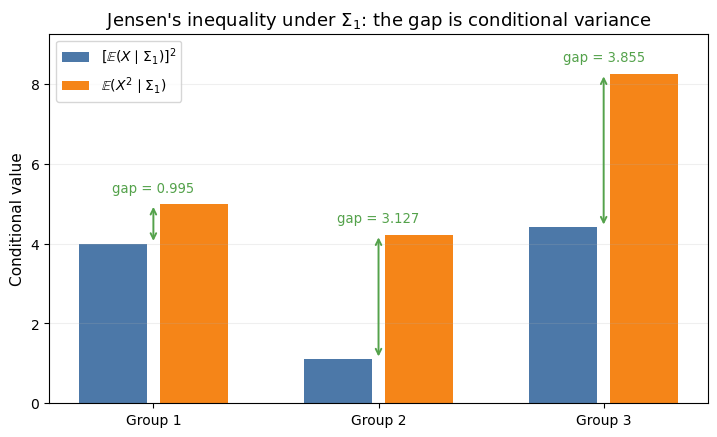

**Minimum Jensen gap:** 0.995

In [5]:
group_labels = ["Group 1", "Group 2", "Group 3"]
conditional_first_moment = []
conditional_second_moment = []

for group in np.unique(coarse_groups):
    mask = coarse_groups == group
    conditional_first_moment.append(state_values[mask].mean())
    conditional_second_moment.append((state_values[mask] ** 2).mean())

left_side = np.square(conditional_first_moment)
right_side = np.asarray(conditional_second_moment)
jensen_gap = right_side - left_side

x_positions = np.arange(len(group_labels))
width = 0.30
offset = 0.18

fig, ax = plt.subplots(figsize=(8.5, 4.8))
ax.bar(
    x_positions - offset,
    left_side,
    width,
    color=BLUE,
    label=r"$[\mathbb{E}(X\mid\Sigma_1)]^2$",
)
ax.bar(
    x_positions + offset,
    right_side,
    width,
    color=ORANGE,
    label=r"$\mathbb{E}(X^2\mid\Sigma_1)$",
)

for position, lower, upper, gap in zip(x_positions, left_side, right_side, jensen_gap):
    ax.annotate(
        "",
        xy=(position, upper),
        xytext=(position, lower),
        arrowprops={"arrowstyle": "<->", "color": GREEN, "lw": 1.4},
    )
    ax.text(
        position,
        upper + 0.22,
        f"gap = {gap:.3f}",
        ha="center",
        va="bottom",
        color=GREEN,
        fontsize=9.5,
    )

ax.set_title(r"Jensen's inequality under $\Sigma_1$: the gap is conditional variance")
ax.set_ylabel("Conditional value")
ax.set_xticks(x_positions, labels=group_labels)
ax.set_ylim(0, right_side.max() + 1.0)
ax.legend()
ax.grid(axis="y", alpha=0.2)
plt.show()

display(Markdown(f"**Minimum Jensen gap:** {jensen_gap.min():.3f}"))

<p class="figure-caption"><strong>Figure 4.</strong> Group-level comparison for conditional Jensen inequality under $\Sigma_1$.</p>

<p class="figure-interpretation"><span class="interpretation-label">Interpretation.</span> In every $\Sigma_1$ group, $\mathbb{E}(X^2\mid\Sigma_1)$ exceeds $[\mathbb{E}(X\mid\Sigma_1)]^2$. The double-headed marker shows the Jensen gap $\operatorname{Var}(X\mid\Sigma_1)=\mathbb E(X^2\mid\Sigma_1)-[\mathbb E(X\mid\Sigma_1)]^2$, the conditional variance within a $\Sigma_1$ group. Its minimum value is $0.995$ in this example.</p>